In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
customer=pd.read_csv('Behavior.csv')

In [3]:
customer.drop(columns=['Age'],inplace=True)

In [22]:
customer['Returns']=customer['Returns'].fillna(0)

In [23]:
customer['Purchase Date']=pd.to_datetime(customer['Purchase Date'])

#  Customer Purchase Analysis
# How can you analyze total spending of each customer using Customer ID and Total Purchase Amount?




In [25]:
customer.groupby('Customer Name')['Total Purchase Amount'].sum().sort_values(ascending=False).reset_index()

,Customer Name,Total Purchase Amount
0,Michael Johnson,339219
1,Michael Smith,321691
2,Michael Brown,299694
3,James Smith,265814
4,Michael Jones,265805
...,...,...
39873,Nicole Foley,194
39874,Chris Weiss,184
39875,Russell Walsh,182
39876,Chad Torres,160


#  Top Selling Product Category 
# Which Product Category generates the highest revenue based on Total Purchase Amount?




Product Category
Home           171138916
Clothing       170716122
Electronics    170146025
Books          169345236
Name: Total Purchase Amount, dtype: int64


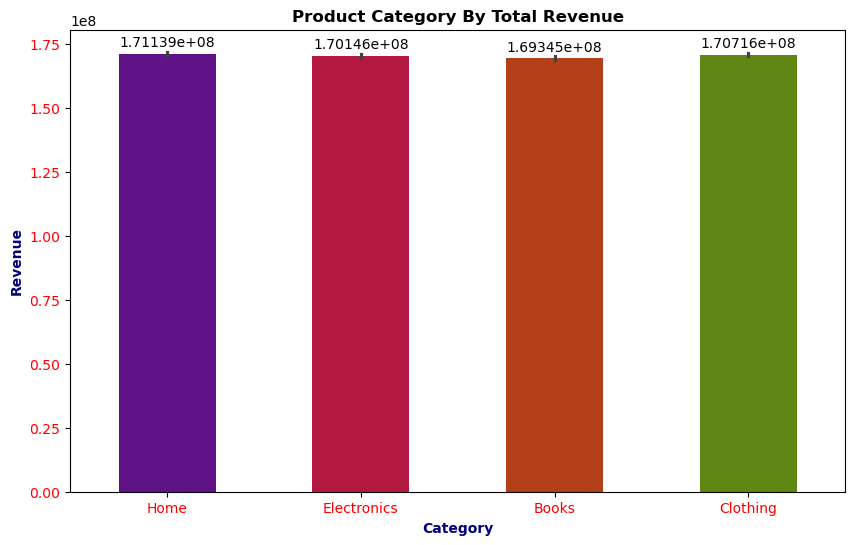

In [27]:

category=customer.groupby('Product Category')['Total Purchase Amount'].sum().sort_values(ascending=False)
print(category)
plt.figure(figsize=(10,6))
ax=sns.barplot(data=customer,x='Product Category',y='Total Purchase Amount',hue='Product Category',palette='brg',width=.5,estimator='sum')
plt.title('Product Category By Total Revenue',color ='black',fontweight='bold')
for container in ax.containers:
    ax.bar_label(container,padding=3)
plt.xlabel('Category',color='navy',fontweight='bold')
plt.ylabel('Revenue',color='navy',fontweight='bold')
plt.xticks(color='red')
plt.yticks(color='red')
plt.show()

#  Payment Method Analysis 
# Which Payment Method is most frequently used and generates the highest sales?



In [30]:
customer.groupby('Payment Method')['Total Purchase Amount'].agg(['count','sum','mean']).round().reset_index()

,Payment Method,count,sum,mean
0,Cash,83012,225423854,2716.0
1,Credit Card,83547,228822915,2739.0
2,PayPal,83441,227099530,2722.0



#  Return Behavior Analysis 
# Is there any relationship between Customer Age and product Returns?




In [32]:
Return=customer[customer['Returns']==1]
Return.groupby('Customer Age')['Returns'].count().reset_index().sort_values(by='Customer Age',ascending=False)

,Customer Age,Returns
52,70,1877
51,69,1924
50,68,1927
49,67,1886
48,66,1970
47,65,1898
46,64,1944
45,63,1892
44,62,1921
43,61,1885


#  Monthly Sales Trend 
# How does total sales change over time based on Purchase Date?




    Monthly  Total Purchase Amount
0         1               62201958
1         2               57050354
2         3               62355745
3         4               60217450
4         5               62533980
5         6               60286066
6         7               62587751
7         8               63063912
8         9               51763012
9        10               46595245
10       11               45604668
11       12               47086158


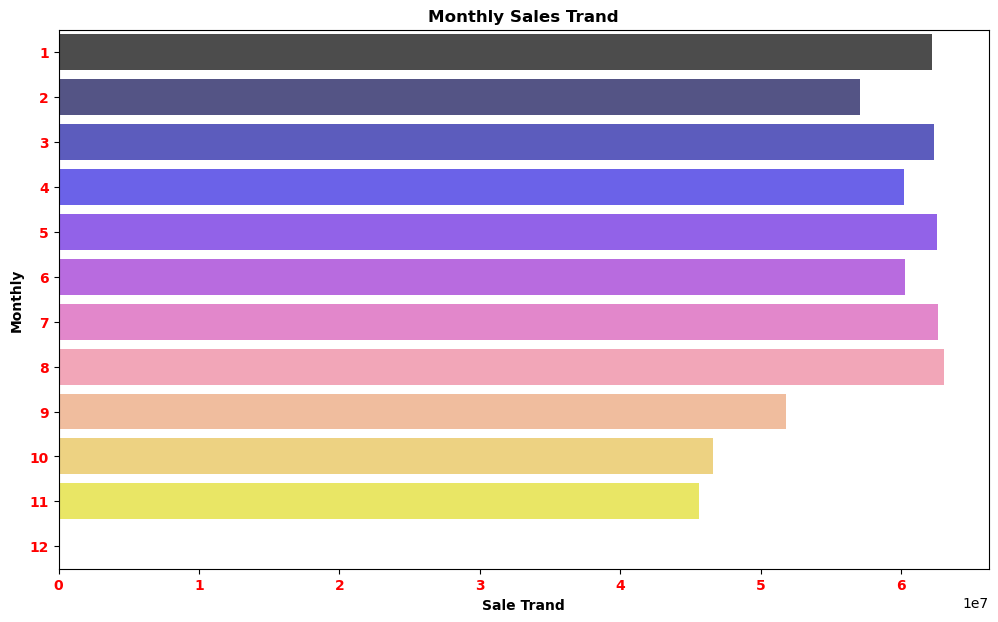

In [3]:
customer['Monthly']=pd.to_datetime(customer['Purchase Date']).dt.month
monthly_sales=customer.groupby('Monthly')['Total Purchase Amount'].sum().reset_index()
print(monthly_sales)
plt.figure(figsize=(12,7))
sns.barplot(data=monthly_sales,x='Total Purchase Amount',y='Monthly',orient='h',palette='gnuplot2',alpha=.7,hue='Monthly',legend=False)
plt.title('Monthly Sales Trand',color='black',fontweight='bold')
plt.xticks(color='red',fontweight='bold')
plt.yticks(color='red',fontweight='bold')
plt.xlabel('Sale Trand',color='black',fontweight='bold')
plt.ylabel('Monthly',color='black',fontweight='bold')
plt.show()

#  High-Value Customers Identification 
# How can you identify high-value customers based on purchase frequency and total spending?




In [36]:
customer.groupby('Customer Name')['Total Purchase Amount'].sum().sort_values(ascending=False).reset_index().head(1)

,Customer Name,Total Purchase Amount
0,Michael Johnson,339219


#  Gender-based Purchase Behavior 
# Do male and female customers show different purchasing patterns in Product Category?



   Gender  Product Price
0  Female       31673187
1    Male       32012494


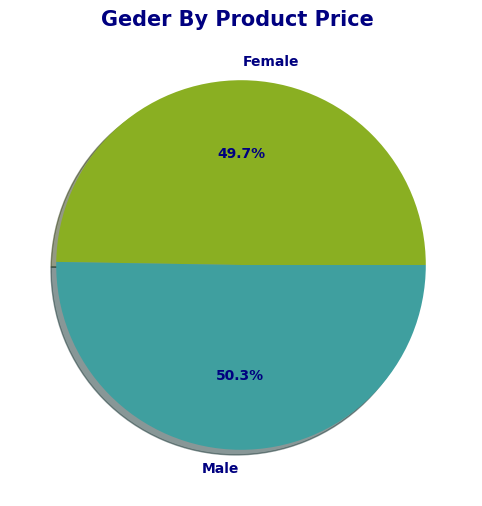

In [38]:
group=customer.groupby('Gender')['Product Price'].sum().reset_index()
print(group)
plt.figure(figsize=(12,6))
plt.pie(group['Product Price'],labels=group['Gender'],autopct='%1.1f%%',colors=['#8AAF22','#3F9F9F'],textprops={'weight':'bold','color':'navy'},shadow=True)
plt.title('Geder By Product Price ',color='navy',fontweight='bold',fontsize=15)
plt.show()

#  Average Order Value Calculation 
# What is the average order value per customer?


In [40]:
customer.groupby('Customer ID')['Total Purchase Amount'].mean().sort_values(ascending=False).reset_index()

,Customer ID,Total Purchase Amount
0,28055,5296.0
1,8255,5274.0
2,19636,5261.0
3,30707,5250.0
4,39466,5241.0
...,...,...
49656,46375,184.0
49657,43125,182.0
49658,41405,160.0
49659,35086,158.0



#  Fraud or Anomaly Detection 
# Can you detect unusual transactions based on extremely high quantity or total amount?




In [77]:
threshold=customer['Total Purchase Amount'].quantile(.99)
anomalies=customer[customer['Total Purchase Amount']>threshold]
print(f"{len(anomalies)}")
print(anomalies.head())

2495
     Customer ID Purchase Date Product Category  Product Price  Quantity  \
30         24053    2020-11-17      Electronics            102         2   
149        34857    2021-01-10            Books            120         3   
201        17203    2022-07-03             Home            160         4   
265          835    2023-01-29      Electronics            306         1   
303         5243    2020-04-03         Clothing            477         1   

     Total Purchase Amount Payment Method  Customer Age  Returns  \
30                    5206    Credit Card            53      1.0   
149                   5279    Credit Card            57      0.0   
201                   5300           Cash            62      0.0   
265                   5281           Cash            59      0.0   
303                   5289         PayPal            70      0.0   

       Customer Name  Age Gender  Churn  Monthly  
30        Jose Green   53   Male      0       11  
149  Alexander Morse   57  

#  Impact of Returns on Churn 
# Do customers who return more products have a higher chance of churn?



-0.004077767187318723


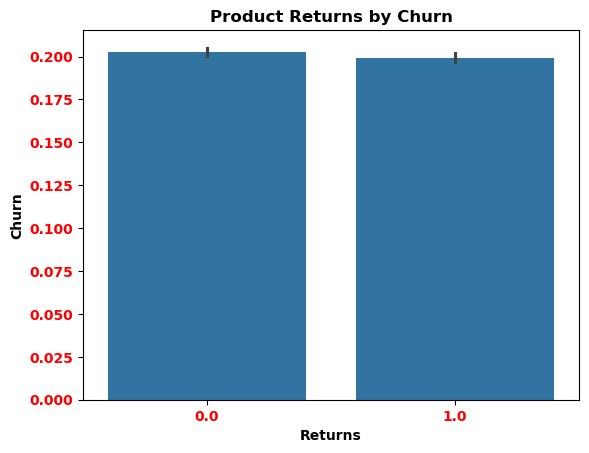

In [12]:
correlation=customer['Returns'].corr(customer['Churn'])

print(correlation)
sns.barplot(x='Returns',y='Churn',data=customer)
plt.title('Product Returns by Churn',color='black',fontweight='bold')
plt.xlabel('Returns',color='black',fontweight='bold')
plt.ylabel('Churn',color='black',fontweight='bold')
plt.xticks(color='red',fontweight='bold')
plt.yticks(color='red',fontweight='bold')
plt.show()


# Best Time to Sell 
# On which dates or periods do sales peak the most?



    Monthly  Total Purchase Amount
0         1               62201958
1         2               57050354
2         3               62355745
3         4               60217450
4         5               62533980
5         6               60286066
6         7               62587751
7         8               63063912
8         9               51763012
9        10               46595245
10       11               45604668
11       12               47086158


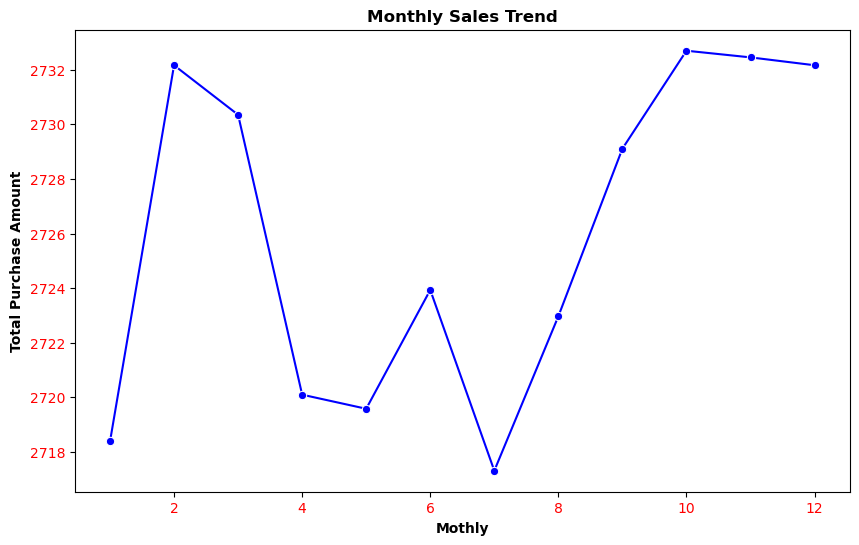

In [94]:
Sales=customer.groupby('Monthly')['Total Purchase Amount'].sum().reset_index()
print(Sales)
plt.figure(figsize=(10,6))
sns.lineplot(data=customer,x='Monthly',y='Total Purchase Amount',color='b',marker='o',errorbar=None)
plt.title('Monthly Sales Trend',color='black',fontweight='bold')
plt.xlabel('Mothly',color='black',fontweight='bold')
plt.ylabel('Total Purchase Amount',color='black',fontweight='bold')
plt.xticks(color='red')
plt.yticks(color='red')
plt.show()

#  Price vs Quantity Relationship 
# Is there any relationship between Product Price and Quantity purchased?




In [9]:
correlation=customer['Quantity'].corr(customer['Product Price'])
print('Relationship product price and Quantity :',correlation)

Relationship product price and Quantity : 0.0023392924271715748


# 15. Customer Lifetime Value (CLV) 
# How can you calculate the lifetime value of a customer using historical purchase data?



In [ ]:
customer

In [11]:
clv=customer.groupby('Customer ID').agg({
    'Total Purchase Amount':'sum',
    'Purchase Date':'count'
}).reset_index()
clv

,Customer ID,Total Purchase Amount,Purchase Date
0,1,6290,3
1,2,16481,6
2,3,9423,4
3,4,7826,5
4,5,9769,5
...,...,...,...
49656,49996,24034,7
49657,49997,5714,2
49658,49998,20495,10
49659,49999,14321,6
